# 79 - Milestone Project: Fashion-MNIST

**Section:** CNN Milestone Projects | **Prereqs:** all of `CNNs/` | **Next:** `CNN Milestone Projects/CIFAR_10.ipynb`

Same shape as MNIST - 28x28 greyscale, 10 classes - but clothing instead of
digits, and substantially harder. MNIST is solved at 99%+; Fashion-MNIST sits
around 93-94%, because shirts, coats and pullovers genuinely look alike at 28x28.

**Read the confusion matrix at the end.** The errors are concentrated in the
upper-body garments (shirt/coat/pullover/T-shirt), and they are the same
confusions a human makes on these thumbnails. When a model's mistakes look like
the ones a person would make, you are near the ceiling of what the data supports.

**The augmentation has to preserve the label.** A horizontal flip of a shirt is
still a shirt, so `RandomHorizontalFlip` is applied to the training set; a
*vertical* flip would produce upside-down garments this dataset never contains
and would teach the model something untrue. The validation pipeline normalises
and nothing else.

**Regularisation is heavy:** dropout, weight decay, L1 and batch norm together.
Watch whether train accuracy is being held down by it - if train and validation
are both low, the model is under-fitting and some of that should come off.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset , Dataset

from torchsummary import summary
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST

In [ ]:
# Fashion-MNIST: 60000 train, 10000 test, 28x28 greyscale, 10 clothing classes.
data = FashionMNIST(root='/root', download=True,train=True)
data_test = FashionMNIST(root='/root', download=True,train=False)

In [ ]:
data.data.type

<function Tensor.type>

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data = data.data
train_label = data.targets

val_data = data_test.data
val_label = data_test.targets

In [ ]:
# The class names, in label order.
categories = data.classes

In [ ]:
categories, len(categories)

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 10)

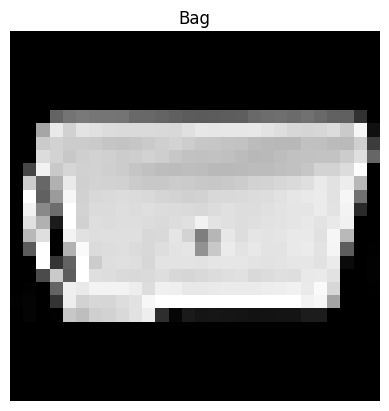

In [ ]:
# Look at a sample. At 28x28, telling a shirt from a coat is hard for a human
# too - which calibrates what accuracy to expect.
plt.imshow(train_data[110].detach().cpu().numpy(), cmap='gray')
plt.title(categories[train_label[110].item()])
plt.axis('off');

In [ ]:
train_data.shape

torch.Size([60000, 28, 28])

In [ ]:
# The training augmentation, attached to the train Dataset below (and only that
# one - the validation set must never be augmented).
# RandomHorizontalFlip, NOT vertical: a mirrored shirt is still a shirt, an
# upside-down shoe is not an input this dataset ever contains. An augmentation
# has to preserve the label.
# Normalize((0.5,),(0.5,)) maps [0,1] to [-1,1]; the tensors are scaled to [0,1]
# in the dataset cell below so this lands in the right range.
train_transormations = T.Compose([
    T.RandomHorizontalFlip(p=0.30),
    T.Normalize((0.5,), (0.5,))
])

val_transformations = T.Compose([
    T.Normalize((0.5,), (0.5,))
])

In [ ]:
train_transormations

Compose(
    RandomVerticalFlip(p=0.3)
    Normalize(mean=(0.5,), std=(0.5,))
)

#### Custom Dataset

In [ ]:
TensorDataset??

In [ ]:
# A custom Dataset taking X and y separately - a cleaner interface than the
# tuple-of-tensors version used elsewhere in this course.
class CustomDataset(Dataset):
    def __init__(self, X,y, transformations=None) -> None:
        if X.shape[0] != y.shape[0]:
            raise AssertionError("Size mismatch between tensors")
        self.X = X
        self.y = y
        self.transform = transformations

    def __getitem__(self, index):
        x = self.X[index]
        y = self.y[index]
        if self.transform:
          x = self.transform(x)
        return x, y

    def __len__(self) -> int:
        return self.X.size(0)

In [ ]:
# .reshape(N,1,28,28) adds the channel axis Conv2d needs, and /255 scales the
# raw uint8 pixels to [0,1] so the Normalize in the pipeline maps them to [-1,1].
# Augmentation is attached to the TRAIN dataset only.
train_dataset = CustomDataset(train_data.reshape(train_data.shape[0],1,28,28).float().to(device) / 255.,
                              train_label.long().to(device), train_transormations)
val_dataset = CustomDataset(val_data.reshape(val_data.shape[0],1,28,28).float().to(device) / 255.,
                            val_label.long().to(device), val_transformations)

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_data.shape[0])


In [ ]:
a,b = next(iter(train_loader))
a.shape

torch.Size([256, 1, 28, 28])

In [ ]:
a.device

device(type='cuda', index=0)

## Designing the model

In [ ]:
# The architecture, parameterised by channel width and classifier width:
#   [Conv -> BatchNorm -> LeakyReLU -> AvgPool] x3, channels doubling each time,
#   then Flatten -> Linear -> Dropout -> ReLU -> Linear -> Dropout -> Linear(10).
# Note Dropout sits BEFORE the ReLU in the first block - unusual (normally after)
# but harmless for ReLU, since dropping a value and then rectifying gives the
# same zeros either way.
# The commented-out AdaptiveAvgPool2d(1) would replace Flatten and cut the
# classifier's parameters by an order of magnitude.
class CNNModel(nn.Module):
  def __init__(self, chan_num, linear_num ) -> None:
    super().__init__()

    self.layers = nn.Sequential(
        nn.Conv2d(1,chan_num, kernel_size=3, padding=1,stride=1), # Output -> [6,28,28] (if chan_num is 6)
        nn.BatchNorm2d(chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [6,14,14]

        nn.Conv2d(chan_num,2*chan_num, kernel_size=3, padding=1,stride=1), # Output -> [12,14,14]
        nn.BatchNorm2d(2*chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [12,7,7]

        nn.Conv2d(2*chan_num,4*chan_num, kernel_size=3, padding=1,stride=1), # Output -> [24,7,7]
        nn.BatchNorm2d(4*chan_num),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [24,3,3]


        # nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(4*chan_num*3*3, linear_num),
        nn.Dropout(p=0.5),
        # nn.BatchNorm1d(linear_num),
        nn.ReLU(),
        nn.Linear(linear_num,linear_num),
        nn.Dropout(p=0.5),
        nn.Linear(linear_num,10)


    )

  def forward(self,x):
    return self.layers(x)

In [ ]:
test_model = CNNModel(64,256).to(device)

In [ ]:
# torchsummary at width 64 - check shapes and see where the parameters live.
summary(test_model, input_size=(1,28,28), batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 64, 28, 28]             640
       BatchNorm2d-2          [128, 64, 28, 28]             128
         LeakyReLU-3          [128, 64, 28, 28]               0
         AvgPool2d-4          [128, 64, 14, 14]               0
            Conv2d-5         [128, 128, 14, 14]          73,856
       BatchNorm2d-6         [128, 128, 14, 14]             256
         LeakyReLU-7         [128, 128, 14, 14]               0
         AvgPool2d-8           [128, 128, 7, 7]               0
            Conv2d-9           [128, 256, 7, 7]         295,168
      BatchNorm2d-10           [128, 256, 7, 7]             512
        LeakyReLU-11           [128, 256, 7, 7]               0
        AvgPool2d-12           [128, 256, 3, 3]               0
          Flatten-13                [128, 2304]               0
           Linear-14                 [1

In [ ]:
# The full regularisation stack used in these milestone projects:
#   Adam with weight_decay=5e-4  (L2),
#   an explicit L1 penalty normalised by the parameter count,
#   Dropout(0.5) between the fully connected layers,
#   BatchNorm after every convolution.
# Four regularisers at once is more than most models need. If the model is
# UNDERfitting (train accuracy low), remove some before adding capacity - see
# Regularization/Dropuout.ipynb for what over-regularisation looks like.
# Note the L1 sum runs over every parameter including biases and BatchNorm
# scales; weights only is the textbook form.
def train_model(chan_num, linear_num):

  model = CNNModel(chan_num, linear_num).to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 50
  optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 5e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [ ]:
# Train at chan_num=256, linear_num=512 - a large model for 28x28 greyscale.
model, losses, train_acc, val_acc = train_model(256,512)

Epoch 0 | Loss : 0.5817 | Train Acc 78.87286376953125 | Val Acc : 86.51000213623047
Epoch 10 | Loss : 0.1701 | Train Acc 93.88521575927734 | Val Acc : 91.72000122070312
Epoch 20 | Loss : 0.0948 | Train Acc 96.61959075927734 | Val Acc : 93.16999816894531
Epoch 30 | Loss : 0.0534 | Train Acc 98.11531829833984 | Val Acc : 93.01000213623047
Epoch 40 | Loss : 0.0359 | Train Acc 98.8231201171875 | Val Acc : 93.72000122070312
Epoch 49 | Loss : 0.0292 | Train Acc 99.06517028808594 | Val Acc : 92.86000061035156


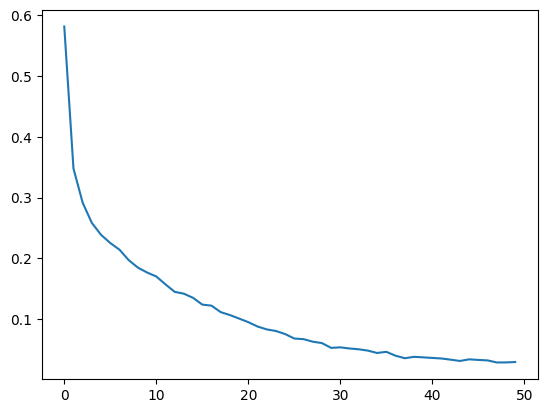

In [ ]:
# Loss curve (includes the L1 term).
plt.plot(losses);

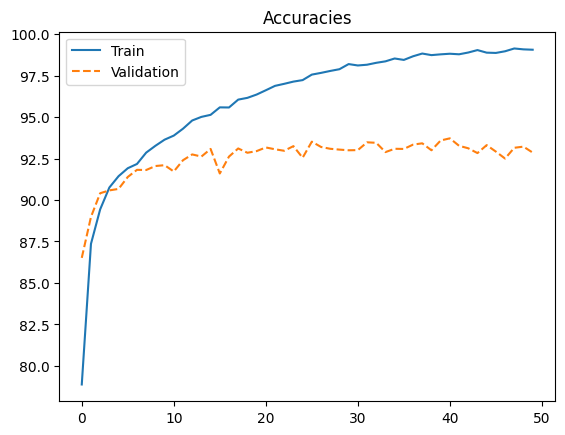

In [ ]:
# Train vs validation accuracy. If the two curves sit close together and both
# below ~93%, the regularisation is too strong rather than too weak.
plt.plot(train_acc, label='Train')
plt.plot(val_acc,'--', label='Validation')
plt.legend()
plt.title("Accuracies");

In [ ]:
# Final evaluation on the validation set.
with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      preds = torch.argmax(model(X), dim=1)
      val_acc = (100 * torch.mean((preds == Y).float()).detach().cpu())

In [ ]:
val_acc

tensor(92.8600)

In [ ]:
# Per-class precision, recall and F1. sklearn's signature is (y_true, y_pred);
# reversing it swaps precision and recall with no warning.
from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(Y.detach().cpu().numpy(), preds.detach().cpu().numpy(), target_names=categories)
print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.91      0.88       929
     Trouser       0.99      0.99      0.99       994
    Pullover       0.93      0.83      0.88      1115
       Dress       0.94      0.92      0.93      1019
        Coat       0.89      0.89      0.89       991
      Sandal       0.98      0.99      0.98       987
       Shirt       0.78      0.83      0.80       950
     Sneaker       0.99      0.94      0.96      1061
         Bag       0.99      0.99      0.99       999
  Ankle boot       0.95      0.99      0.97       955

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [ ]:
c_matrix = confusion_matrix(Y.detach().cpu().numpy(), preds.detach().cpu().numpy())

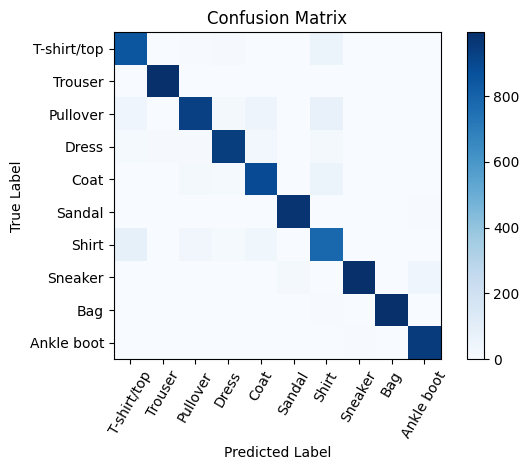

In [ ]:
# The confusion matrix - the payoff of this notebook.
# Expect a bright block among shirt / coat / pullover / T-shirt, and near-perfect
# separation for trouser, bag and sandal. Those confusions are the ones a human
# makes too, which means the model is near the limit of what 28x28 supports.
plt.imshow(c_matrix, cmap='Blues')
plt.xticks(range(len(categories)), categories, rotation=60)
plt.yticks(range(len(categories)), categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()